# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

# Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/502f5eb5a6e82c697dc3bb19469b4786eb2b13c3/12.%20Random%20Forest/data/glass.xlsx"
excel_file = pd.ExcelFile(url)

In [3]:
excel_file.sheet_names

['Description', 'glass']

In [4]:
df = pd.read_excel(excel_file, sheet_name = "glass")

# Preview of the Dataset

In [5]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


# Initial Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


## Dataset Dimensions

In [7]:
print("Shape : ",df.shape)
print("Size : ",df.size)

Shape :  (214, 10)
Size :  2140


## Check DataTypes

In [8]:
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


In [9]:
df["Type"].value_counts()

,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


### Observation :

- The target variable `Type` has total of 6 classes.
- The `1 and 2 classes`  has the most number of records.

# Data Cleaning

## Checking Duplicate Records and Missing Values

In [10]:
print("No.of Duplicate Records : ",df.duplicated().sum())

No.of Duplicate Records :  1


In [11]:
print("No.of Missing values : ")
print(df.isnull().sum())

No.of Missing values : 
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


### Missing Value Handling

The dataset contains no missing values. Therefore, no imputation or row/column removal was required. The dataset was used directly for further preprocessing and model development.

## Removing Duplicate Records

In [12]:
df.drop_duplicates(inplace=True)
print("No.of Duplicate Records after removal: ",df.duplicated().sum())

No.of Duplicate Records after removal:  0


## Cleaned Dataset Dimensions

In [13]:
print("Shape after cleaning : ",df.shape)
print("Size after cleaning : ",df.size)

Shape after cleaning :  (213, 10)
Size after cleaning :  2130


In [14]:
print(df.dtypes)

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object


### Observation :

The Cleaned Dataset contains 213 records and 10 variables where all variables are type `float64` except the target column `Type` which is `int64`.

# Descriptive Statistical Analysis

In [15]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [16]:
print("Mode : \n",df.mode().iloc[0])

Mode : 
 RI       1.5159
Na      13.0000
Mg       0.0000
Al       1.5400
Si      72.8600
K        0.0000
Ca       8.0300
Ba       0.0000
Fe       0.0000
Type     2.0000
Name: 0, dtype: float64


## Observation :

- The Descriptive Statistics shows that `Na`,`Al`,`K`,`Ca`,`Ba`,`Fe`columns may have potential outliers.
- The variables `Mg`,`K`,`Ba`,`Fe` contain many `0`values, indicating highly concentrated or sparse distributions for these features.


# Exploratory Data Analysis

In [17]:
numerical_cols = df.drop(columns = "Type").columns
categorical_col = ["Type"]
print("Categorical Columns : \n",categorical_col)
print("="*100)
print("Numerical Columns : \n",numerical_cols)

Categorical Columns : 
 ['Type']
Numerical Columns : 
 Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='object')


## Boxplot Analysis

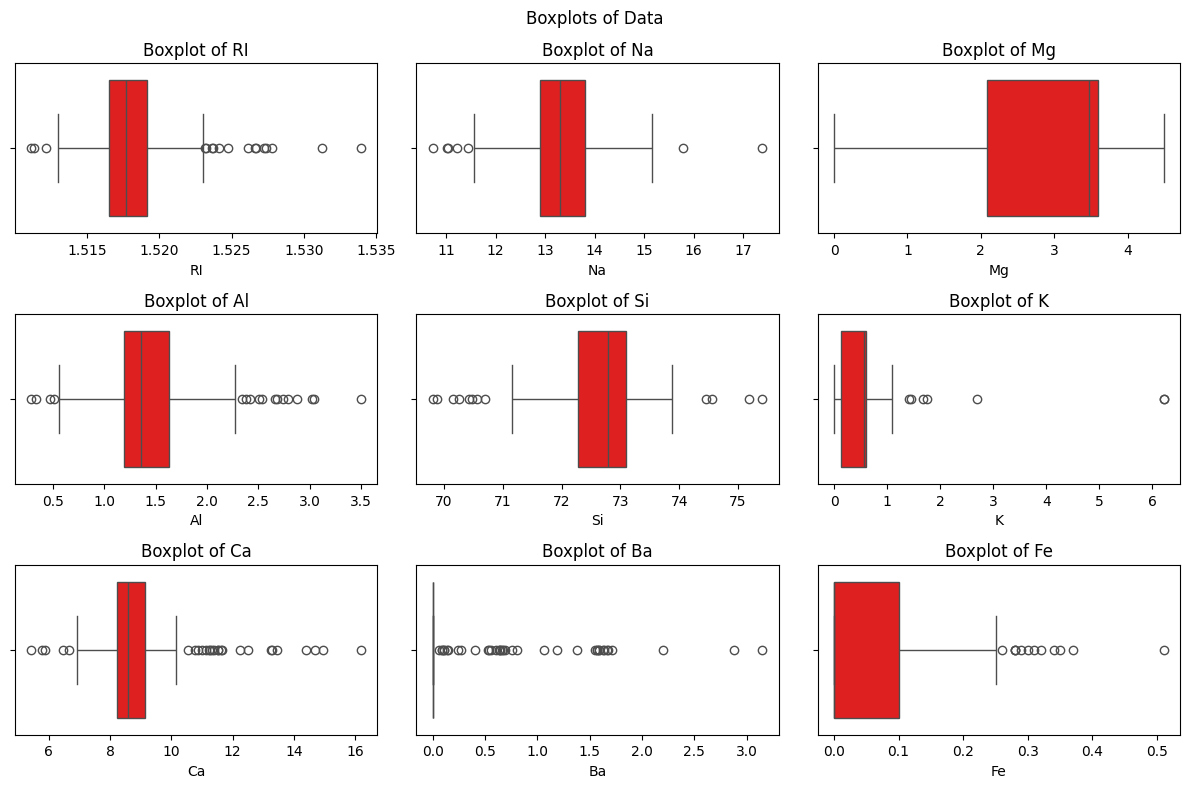

In [18]:
fig,ax = plt.subplots(3,3,figsize=(12,8))

for axis,col in zip(ax.flat,numerical_cols):
  sns.boxplot(data=df,x=col,ax=axis,color="red")
  axis.set_title(f"Boxplot of {col}")
  axis.set_xlabel(col)

plt.suptitle("Boxplots of Data")
plt.tight_layout()
plt.show()

### Observation

Boxplots indicate the presence of outliers in several numerical features, particularly `Ba`, `Ca`, `RI`, and `Fe`. These observations were retained because they may represent genuine variations in the chemical composition of different glass types. Additionally, Random Forest models are relatively less sensitive to outliers compared to distance-based models.

## Histogram Analysis

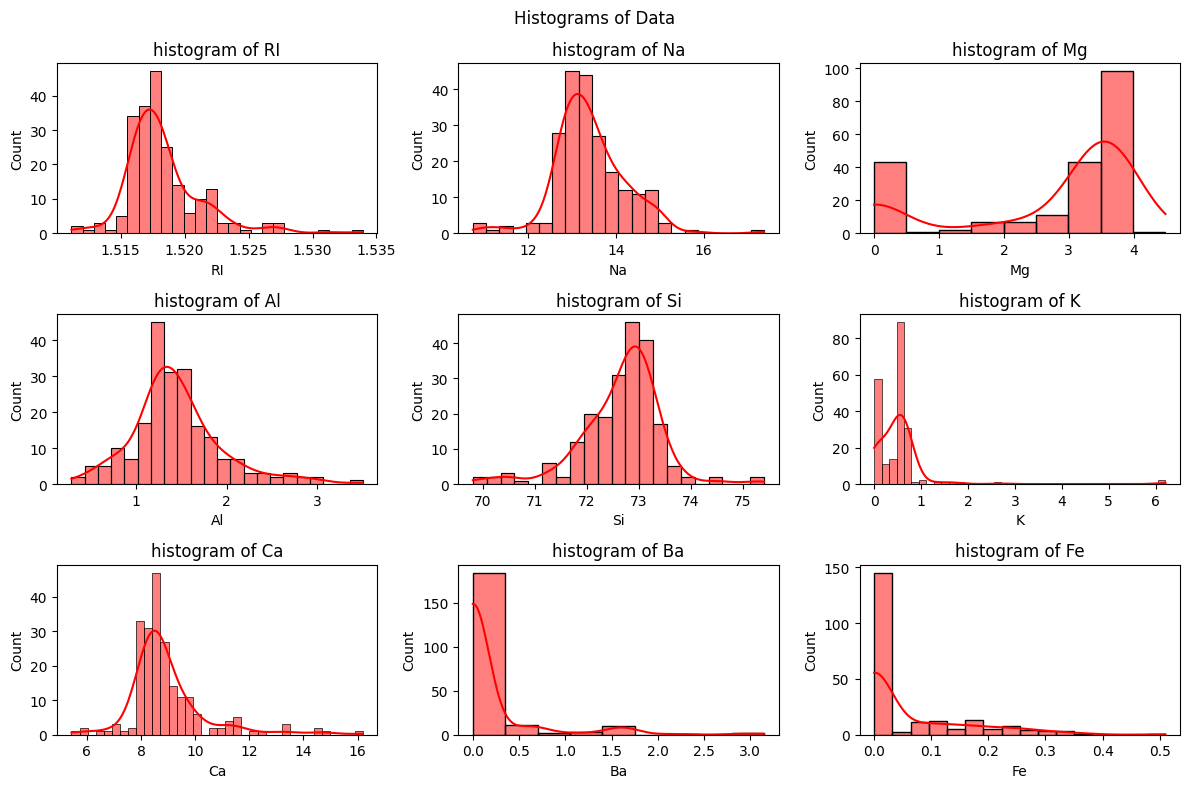

In [19]:
fig,ax = plt.subplots(3,3,figsize=(12,8))

for axis,col in zip(ax.flat,numerical_cols):
  sns.histplot(data=df,x=col,ax=axis,color="red",kde=True)
  axis.set_title(f"histogram of {col}")
  axis.set_xlabel(col)

plt.suptitle("Histograms of Data")
plt.tight_layout()
plt.show()

### Observation :

- Most of the variables have centered distribution except `Mg`,
`K`,`Ba`,`Fe`.
- The Histogram of `Mg` shows it had a Bimodal distribution.
- The Histogram also shows that `K`,`Ba` and `Fe` are strongly right skewed.

## Countplot Analysis

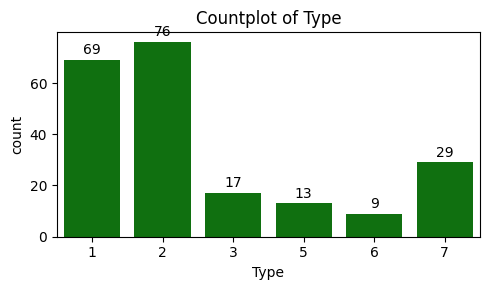

In [20]:
fig,ax = plt.subplots(figsize=(5,3))

sns.countplot(data=df,x="Type",ax=ax,color="green")
ax.set_title(f"Countplot of Type")
ax.set_xlabel("Type")

for container in ax.containers:
  ax.bar_label(container,padding=2)

plt.tight_layout()
plt.show()

### Observation :

- The countplot of Type shows that the `classes 1 and 2` has more no.of records in Target column `Type`.
- The countplot also shows that there is imbalance of classes.

## Outlier Analysis

Boxplots indicate the presence of outliers in several numerical features. However, these observations were retained because they may represent genuine variations in the chemical composition of different glass types. Additionally, Random Forest models are relatively less sensitive to outliers compared to distance-based models.

## Correlation Analysis

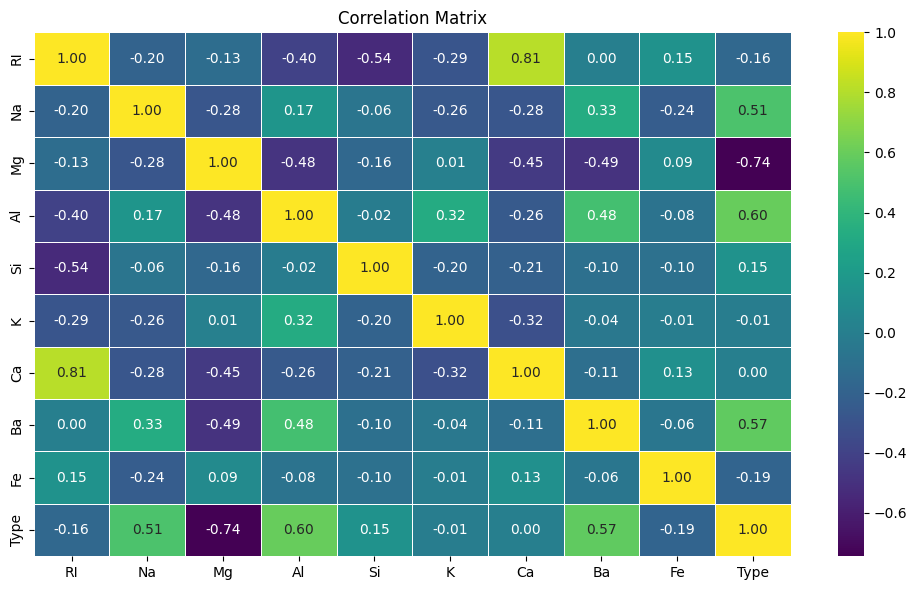

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="viridis",linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Observation

- The correlation matrix shows relationships among the numerical features in the dataset.
- Some features show moderate positive or negative correlations with each other, indicating potential relationships between the chemical composition variables.
- Since `Type` represents categorical class labels, correlations involving `Type` should be interpreted cautiously.
- Additionally, Random Forest can capture non-linear relationships and feature interactions that may not be visible through correlation analysis alone.

# Data preprocessing

## Handling Imbalanced Data

The target variable contains classes with unequal numbers of observations, indicating class imbalance. To preserve the class distribution, stratified sampling was used during the train-test split.

Additionally, weighted Precision, Recall, and F1-score were used for model evaluation so that the performance of all classes was considered according to their support.

More aggressive techniques such as oversampling or SMOTE were not applied because some minority classes contain very few observations, and generating synthetic samples could potentially introduce unreliable patterns into this small dataset.

## Feature and Target Separation

In [22]:
X = df.drop(columns = "Type")
y = df["Type"]

print("X Shape : ",X.shape)
print("y Shape : ",y.shape)

X Shape :  (213, 9)
y Shape :  (213,)


In [23]:
print("Target Distribution : ")
print(y.value_counts())

Target Distribution : 
Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64


## Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20,stratify = y, random_state=42 )
print("X_train : ",X_train.shape)
print("X_test : ",X_test.shape)
print("y_train : ",y_train.shape)
print("y_test : ",y_test.shape)


X_train :  (170, 9)
X_test :  (43, 9)
y_train :  (170,)
y_test :  (43,)


## Feature Scaling

In [25]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

# Random Forest

## Model Training

In [26]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_Scaled,y_train)

RandomForestClassifier(random_state=42)

## Prediction

In [27]:
y_pred = model.predict(X_test_Scaled)

print("Actual Outcome : ")
print(y_test.value_counts())
print("="*50)
print("Predicted Outcome : ")
print(pd.Series(y_pred).value_counts())

Actual Outcome : 
Type
2    15
1    14
7     6
5     3
3     3
6     2
Name: count, dtype: int64
Predicted Outcome : 
1    15
2    14
7     6
5     3
6     3
3     2
Name: count, dtype: int64


## Evaluation Metrics

In [28]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred,average ="weighted",zero_division = 0)
recall = recall_score(y_test,y_pred,average ="weighted",zero_division = 0)
f1 = f1_score(y_test,y_pred,average ="weighted",zero_division = 0)

eval_summary = pd.DataFrame({"Accuracy": [accuracy],"Precision":[precision],
                             "Recall": [recall],"F1":[f1]})
print(eval_summary)

   Accuracy  Precision    Recall        F1
0  0.860465   0.867996  0.860465  0.859663


In [29]:
report = classification_report(y_test,y_pred,zero_division = 0)
print(report)

              precision    recall  f1-score   support

           1       0.87      0.93      0.90        14
           2       0.86      0.80      0.83        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.86        43
   macro avg       0.84      0.84      0.83        43
weighted avg       0.87      0.86      0.86        43



### Inference :

The Random Forest model demonstrates strong overall performance; however, performance on minority classes should be interpreted cautiously because of the limited number of samples available for those classes.

## Confusion Matrix

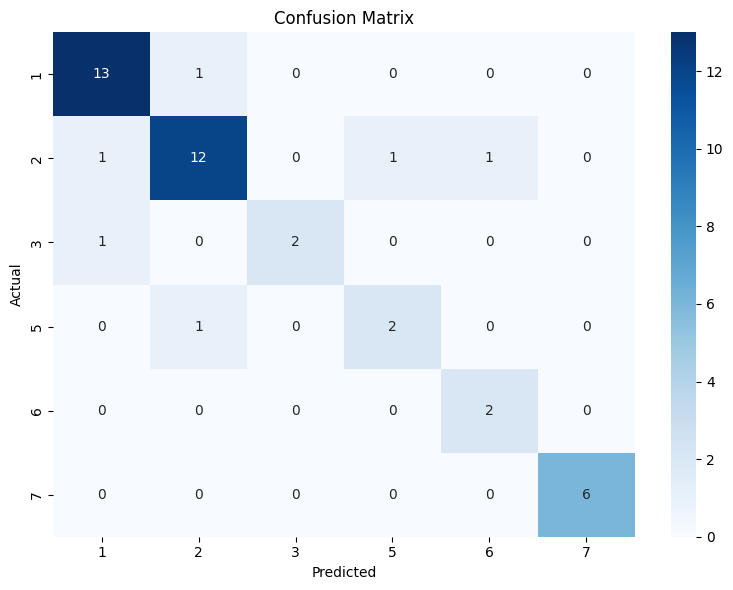

In [30]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize = (8,6))
sns.heatmap(cm,annot = True,fmt="d",cmap="Blues",
            xticklabels = model.classes_,
            yticklabels = model.classes_)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Observation :

The Random Forest model correctly classified most observations, as indicated by the high values along the diagonal of the confusion matrix. Classes 1, 2, and 7 were classified particularly well, while a few misclassifications occurred between classes 1, 2, 3, 5, and 6. The perfect classification of class 7 is notable, though results for minority classes should be interpreted cautiously due to their small sample sizes.

# Bagging

## Model Training

In [31]:
base_model = DecisionTreeClassifier(random_state=42)

bagging_model = BaggingClassifier(estimator = base_model,
                                  n_estimators = 100,
                                  random_state = 42)
bagging_model.fit(X_train_Scaled,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, random_state=42)

## Prediction

In [32]:
y_pred_bagging = bagging_model.predict(X_test_Scaled)

## Evaluation Metrics

In [33]:
accuracy_bagging = accuracy_score(y_test,y_pred_bagging)
precision_bagging = precision_score(y_test,y_pred_bagging,average="weighted",zero_division=0)
recall_bagging = recall_score(y_test,y_pred_bagging,average="weighted",zero_division=0)
f1_bagging = f1_score(y_test,y_pred_bagging,average="weighted",zero_division=0)
eval_summary_bagging = pd.DataFrame({"Accuracy": [accuracy_bagging],"Precision":[precision_bagging],
                             "Recall": [recall_bagging],"F1":[f1_bagging]})
print(eval_summary_bagging)

   Accuracy  Precision    Recall        F1
0  0.767442   0.768166  0.767442  0.764841


In [34]:
report_bagging = classification_report(y_test,y_pred_bagging,zero_division=0)
print(report_bagging)

              precision    recall  f1-score   support

           1       0.77      0.71      0.74        14
           2       0.79      0.73      0.76        15
           3       0.67      0.67      0.67         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.77        43
   macro avg       0.74      0.80      0.76        43
weighted avg       0.77      0.77      0.76        43



## Inference :

The Bagging Classifier achieved an overall accuracy of 76.74% with a weighted F1-score of 76.48%, indicating reasonably good classification performance. The model performed particularly well for Class 7, achieving a recall of 100%, while Classes 1 and 2 showed moderate performance. However, the results for minority classes should be interpreted cautiously because they contain very few samples. Overall, the Bagging model performed reasonably well but was less effective than the Random Forest model.

## Confusion Matrix

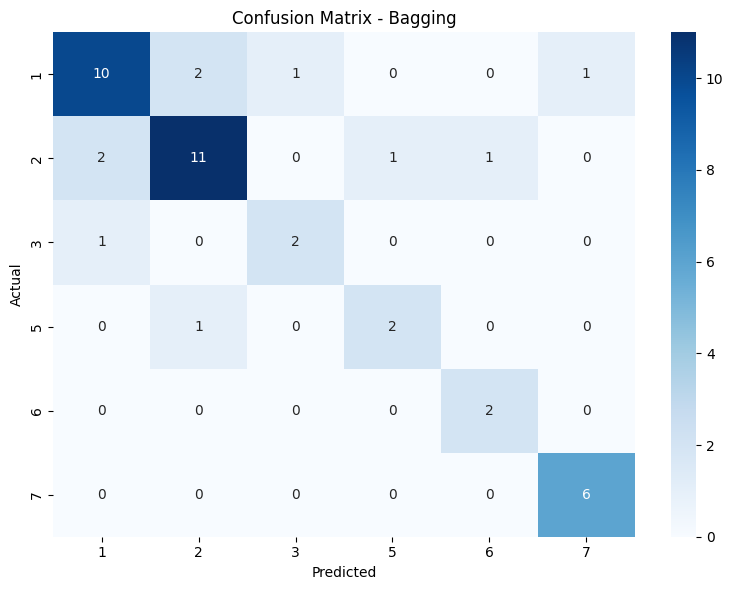

In [35]:
cm_bagging = confusion_matrix(y_test,y_pred_bagging)
plt.figure(figsize = (8,6))
sns.heatmap(cm_bagging,annot = True,fmt="d",cmap="Blues",
            xticklabels = model.classes_,
            yticklabels = model.classes_)
plt.title("Confusion Matrix - Bagging")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Observation :

The confusion matrix shows that most predictions lie along the diagonal, indicating correct classifications. Classes 6 and 7 were classified perfectly, while Classes 1 and 2 had some misclassifications between each other. A few errors also occurred for Classes 3 and 5. Overall, the Bagging Classifier demonstrates reasonable classification performance, but the off-diagonal values indicate more prediction errors compared to the Random Forest model.

# Boosting

## Model Training

In [36]:
boosting_model = AdaBoostClassifier(n_estimators=100,random_state=42)
boosting_model.fit(X_train_Scaled,y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

## Prediction

In [37]:
y_pred_boosting = boosting_model.predict(X_test_Scaled)

## Evaluation Metrics

In [38]:
accuracy_boosting = accuracy_score(y_test,y_pred_boosting)
precision_boosting = precision_score(y_test,y_pred_boosting,average="weighted",zero_division=0)
recall_boosting = recall_score(y_test,y_pred_boosting,average="weighted",zero_division=0)
f1_boosting = f1_score(y_test,y_pred_boosting,average="weighted",zero_division=0)
eval_summary_boosting = pd.DataFrame({"Accuracy": [accuracy_boosting],"Precision":[precision_boosting],
                             "Recall": [recall_boosting],"F1":[f1_boosting]})
print(eval_summary_boosting)

   Accuracy  Precision    Recall        F1
0  0.395349    0.38528  0.395349  0.385733


In [39]:
report_boosting = classification_report(y_test,y_pred_boosting,zero_division=0)
print(report_boosting)

              precision    recall  f1-score   support

           1       0.54      0.50      0.52        14
           2       0.33      0.40      0.36        15
           3       0.00      0.00      0.00         3
           5       0.14      0.33      0.20         3
           6       0.00      0.00      0.00         2
           7       0.60      0.50      0.55         6

    accuracy                           0.40        43
   macro avg       0.27      0.29      0.27        43
weighted avg       0.39      0.40      0.39        43



## Inference :

The AdaBoost Classifier achieved an accuracy of 39.53% and a weighted F1-score of 38.57%, indicating relatively poor performance compared to Random Forest and Bagging. The model showed moderate performance for Classes 1, 2, and 7, but failed to correctly classify Classes 3 and 6. This suggests that AdaBoost, with the current configuration, was not well suited to this dataset.

## Confusion Matrix

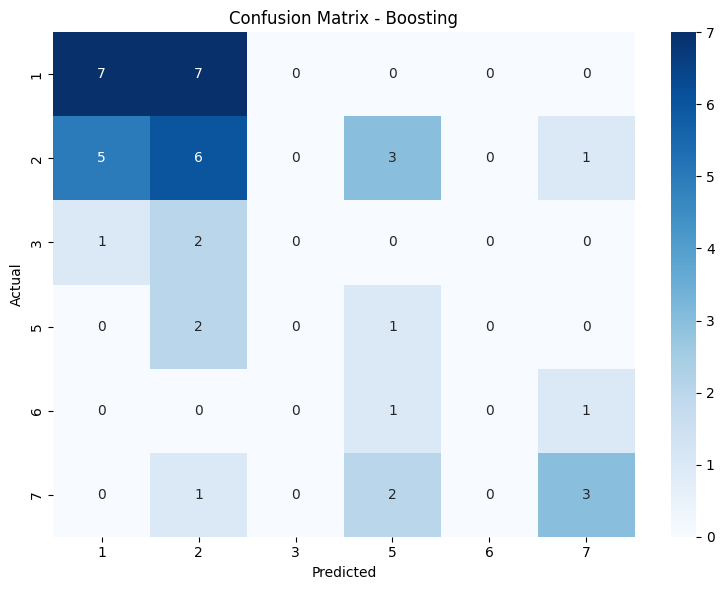

In [40]:
cm_boosting = confusion_matrix(y_test,y_pred_boosting)
plt.figure(figsize = (8,6))
sns.heatmap(cm_boosting,annot = True,fmt="d",cmap="Blues",
            xticklabels = model.classes_,
            yticklabels = model.classes_)
plt.title("Confusion Matrix - Boosting")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Observation :

The confusion matrix shows a large number of predictions outside the diagonal, indicating frequent misclassifications. The model particularly struggled with Classes 3 and 6, with no correct predictions for these classes. Classes 1, 2, and 7 had some correct classifications but were often confused with other classes. Overall, the confusion matrix confirms that the Boosting model performed poorly on this dataset compared to the other ensemble methods.

# Comparing Random Forest Vs Bagging Vs Boosting

In [41]:
Final_Comparison = pd.concat([eval_summary,eval_summary_bagging,eval_summary_boosting],
                              ignore_index = True)
Final_Comparison.index = ["RandomForest","Bagging","Boosting"]
print(Final_Comparison)

              Accuracy  Precision    Recall        F1
RandomForest  0.860465   0.867996  0.860465  0.859663
Bagging       0.767442   0.768166  0.767442  0.764841
Boosting      0.395349   0.385280  0.395349  0.385733


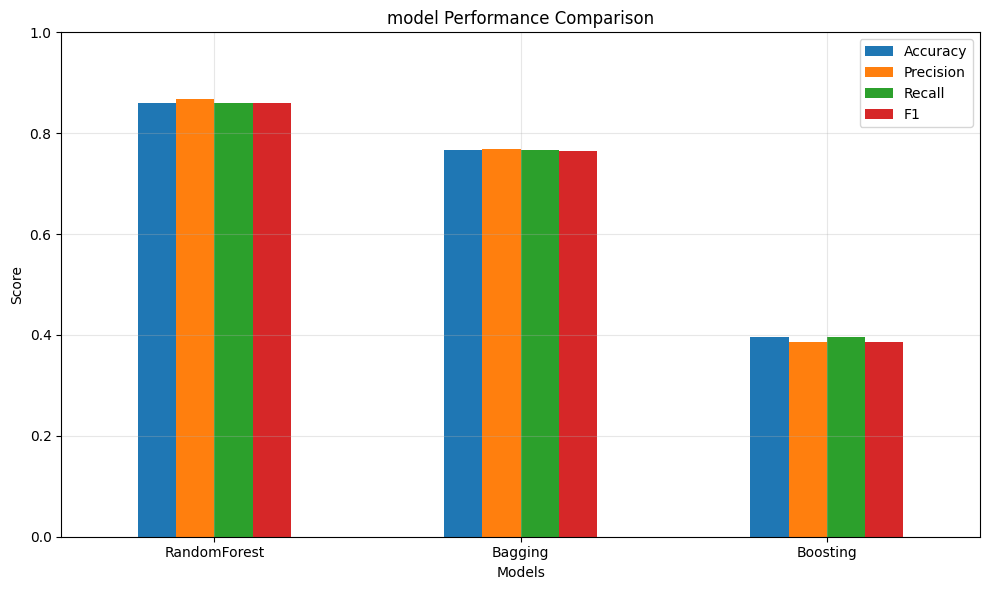

In [42]:
Final_Comparison.plot(kind="bar",figsize=(10,6))
plt.title("model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation = 0)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Observation :

Random Forest achieved the best overall performance across all evaluation metrics, followed by the Bagging Classifier. AdaBoost produced the lowest performance. Therefore, Random Forest appears to be the most suitable model for classifying the Glass dataset among the models evaluated.

# Conclusion

In this assignment, the **Glass dataset** was analyzed using Exploratory Data Analysis (EDA), preprocessing techniques, and multiple ensemble learning models.

The dataset was checked for **missing values, duplicates, outliers, and feature distributions**. Feature scaling was performed using **StandardScaler**, and the data was divided into training and testing sets using a stratified split.

Three ensemble-based models were implemented and evaluated:

- **Random Forest Classifier**
- **Bagging Classifier**
- **AdaBoost Classifier**

Among the evaluated models, **Random Forest achieved the best performance**, with an accuracy of approximately **86.05%** and a weighted F1-score of **85.97%**. The Bagging Classifier achieved an accuracy of approximately **76.74%**, while AdaBoost produced the lowest performance with an accuracy of approximately **39.53%**.

Therefore, based on the evaluation metrics, **Random Forest was the most suitable model for this dataset**. Its ability to combine multiple decision trees and capture complex relationships between features contributed to its superior performance.

Overall, this analysis demonstrates that different ensemble learning techniques can produce significantly different results on the same dataset, highlighting the importance of evaluating and comparing multiple models before selecting the final model.

# Interview Questions

## 1. Explain Bagging and Boosting methods. How is it different from each other.

### Bagging (Bootstrap Aggregating)

Bagging is an ensemble learning technique in which multiple models are trained independently using different random samples of the training dataset. The final prediction is obtained by combining the predictions of all models, usually through majority voting for classification problems.

The main objective of Bagging is to **reduce variance and improve model stability**.

**Example:** Random Forest is a popular Bagging-based ensemble algorithm.

### Boosting

Boosting is an ensemble learning technique in which models are trained sequentially. Each new model focuses more on correcting the errors made by the previous models.

The main objective of Boosting is to **improve overall predictive performance by reducing bias**.

**Example:** AdaBoost is a popular Boosting algorithm.

### Difference Between Bagging and Boosting

| Bagging | Boosting |
|---|---|
| Models are trained independently. | Models are trained sequentially. |
| Primarily reduces variance. | Primarily reduces bias. |
| Each model receives a random sample of the data. | Each model focuses more on previous prediction errors. |
| Models can be trained in parallel. | Models depend on previous models. |
| Example: Random Forest. | Example: AdaBoost. |

## 2. Explain how to handle imbalance in the data.

Imbalanced data occurs when some classes have significantly more observations than others. This can cause a machine learning model to perform well on majority classes while performing poorly on minority classes.

Several techniques can be used to handle imbalanced data:

- **Oversampling:** Increase the number of samples in minority classes.
- **Undersampling:** Reduce the number of samples from majority classes.
- **SMOTE:** Generate synthetic samples for minority classes.
- **Class Weights:** Assign higher importance to minority classes during model training.
- **Appropriate Evaluation Metrics:** Use Precision, Recall, F1-score, and Confusion Matrix instead of relying only on Accuracy.
- **Stratified Sampling:** Maintain the class distribution when splitting the dataset into training and testing sets.

For this dataset, **stratified train-test splitting** was used to preserve the class distribution in both training and testing datasets. Additionally, weighted evaluation metrics were used because the dataset contains classes with different numbers of observations.